<a href="https://colab.research.google.com/github/tejasrisirisha/Data-Analysis-Projects/blob/main/Retail_sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#reading dataset
df = pd.read_csv("/content/sales-dataset.csv")

In [5]:
#Displaying the data

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [7]:
df.shape

(9800, 18)

In [8]:
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [10]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [11]:
#cleaning the dataset

In [12]:

df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [13]:
df = df.dropna()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.drop_duplicates()

In [16]:
df.shape

(9789, 18)

In [17]:
# performing calculations

In [18]:
df["Sales"].mean()

np.float64(230.1161929410563)

In [19]:
df["Sales"].median()

54.384

In [20]:
df["Sales"].mode()

,Sales
0,12.96


In [21]:
df["Sales"].var()

391002.6900158419

In [22]:
df["Sales"].std()

625.3020790112903

In [23]:
df["Sales"].describe()

,Sales
count,9789.000000
mean,230.116193
std,625.302079
min,0.444000
25%,17.248000
50%,54.384000
75%,210.392000
max,22638.480000


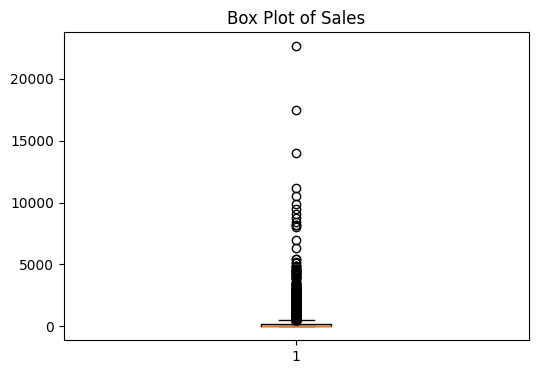

In [24]:
# detecting outliers using box plot
plt.figure(figsize=(6,4))
plt.boxplot(df["Sales"])
plt.title("Box Plot of Sales")
plt.show()

In [25]:
# using quartile
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [26]:
# removing outliers
df = df[(df["Sales"] >= lower) & (df["Sales"] <= upper)]

In [27]:
df.shape

(8648, 18)

In [28]:
# category and region wise sales analysis

In [29]:
category_sales = df.groupby("Category")["Sales"].sum()
print(category_sales)

Category
Furniture          242870.1948
Office Supplies    337876.4700
Technology         225107.1750
Name: Sales, dtype: float64


In [30]:
region_sales = df.groupby("Region")["Sales"].sum()
print(region_sales)

Region
Central    180207.3958
East       228944.6680
South      127024.6415
West       269677.1345
Name: Sales, dtype: float64


In [ ]:
# visualization

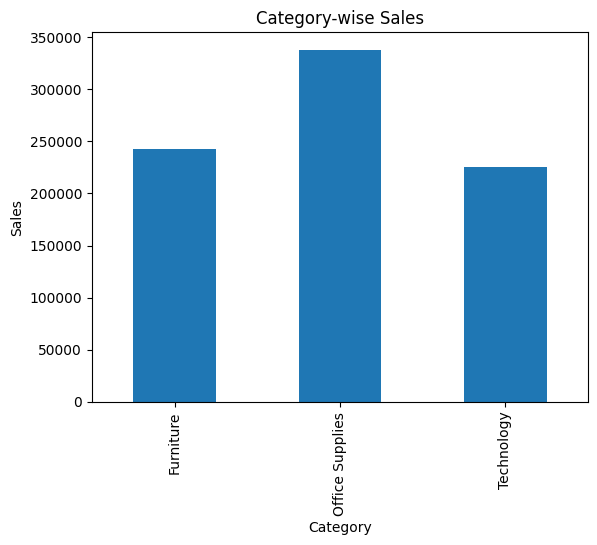

In [31]:
category_sales.plot(kind="bar")
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

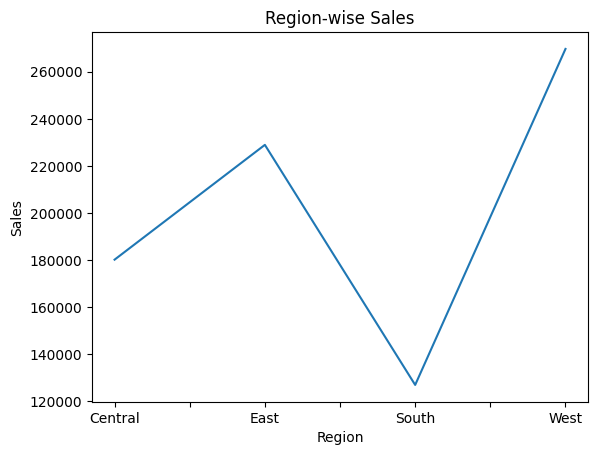

In [32]:
region_sales.plot(kind="line")
plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

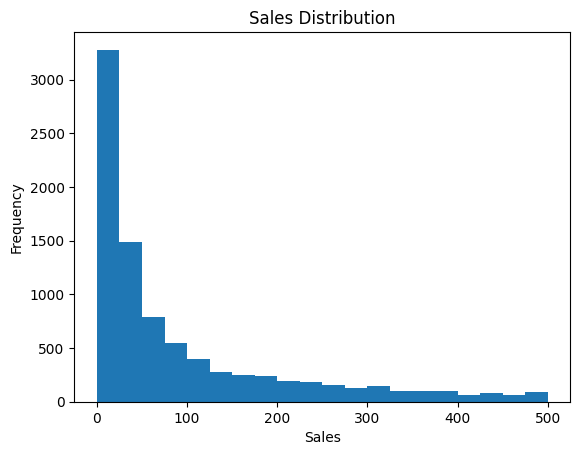

In [33]:
plt.hist(df["Sales"], bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

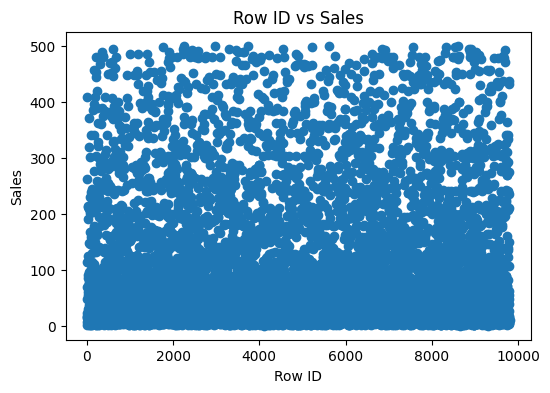

In [34]:
plt.figure(figsize=(6,4))
plt.scatter(df["Row ID"], df["Sales"])
plt.title("Row ID vs Sales")
plt.xlabel("Row ID")
plt.ylabel("Sales")
plt.show()

In [35]:
df.shape

(8648, 18)